In [ ]:
  # Importar librerias

import pandas as pd
import numpy as np
from scipy import stats as st
import statsmodels.stats.proportion as smp
import math as mth
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
from plotly import graph_objects as go

In [ ]:
# Cargar dataset
data = pd.read_csv('/content/sample_data/logs_exp_us.csv', delimiter='\t')

# Preparar los datos para el analisis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [ ]:
print(data.head())

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248


In [ ]:
# Renombrar columnas
data.columns = ['event', 'user_id', 'date_and_time', 'group']

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   event          244126 non-null  object
 1   user_id        244126 non-null  int64 
 2   date_and_time  244126 non-null  int64 
 3   group          244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [ ]:
print('Filas duplicadas:', data.duplicated().sum())
print('Total de filas:', len(data))

print('Porcentaje de filas duplicadas:', '{0:.2f}'.format(data.duplicated().sum() / len(data) * 100), '%')


Filas duplicadas: 413
Total de filas: 244126
Porcentaje de filas duplicadas: 0.17 %


Las filas duplicadas suponen el 0.17% del total de las filas, es seguro eliminarlas sin que afecten nuestro análisis.

In [ ]:
# Eliminar filas duplicadas
data.drop_duplicates(inplace=True)
data.reset_index(inplace=True, drop=True)

print('Filas duplicadas:', data.duplicated().sum())

Filas duplicadas: 0


In [ ]:
# Traduccion de datos de la columna 'date_and_time'
data['date_and_time'] = pd.to_datetime(data['date_and_time'], unit='s')

print(data.head(10))

                     event              user_id       date_and_time  group
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36    246
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42    246
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47    248
3         CartScreenAppear  3518123091307005509 2019-07-25 11:28:47    248
4  PaymentScreenSuccessful  6217807653094995999 2019-07-25 11:48:42    248
5         CartScreenAppear  6217807653094995999 2019-07-25 11:48:43    248
6       OffersScreenAppear  8351860793733343758 2019-07-25 14:50:42    246
7         MainScreenAppear  5682100281902512875 2019-07-25 20:14:37    246
8         MainScreenAppear  1850981295691852772 2019-07-25 20:31:42    247
9         MainScreenAppear  5407636962369102641 2019-07-26 03:35:12    246


In [ ]:
# Agregar nuevas columnas 'date' con la fecha y 'time' con la hora
data['date'] = data['date_and_time'].dt.date
data['time'] = data['date_and_time'].dt.time

print(data.head(10))

                     event              user_id       date_and_time  group  \
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36    246   
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42    246   
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47    248   
3         CartScreenAppear  3518123091307005509 2019-07-25 11:28:47    248   
4  PaymentScreenSuccessful  6217807653094995999 2019-07-25 11:48:42    248   
5         CartScreenAppear  6217807653094995999 2019-07-25 11:48:43    248   
6       OffersScreenAppear  8351860793733343758 2019-07-25 14:50:42    246   
7         MainScreenAppear  5682100281902512875 2019-07-25 20:14:37    246   
8         MainScreenAppear  1850981295691852772 2019-07-25 20:31:42    247   
9         MainScreenAppear  5407636962369102641 2019-07-26 03:35:12    246   

         date      time  
0  2019-07-25  04:43:36  
1  2019-07-25  11:11:42  
2  2019-07-25  11:28:47  
3  2019-07-25  11:28:47  
4  2019-07-

# Estudiar y comprobar los datos

In [ ]:
# Evetos en el registro
print(data['event'].nunique(), 'eventos en los registros:')

for event in data['event'].unique():
  print('-', event)

5 eventos en los registros:
- MainScreenAppear
- PaymentScreenSuccessful
- CartScreenAppear
- OffersScreenAppear
- Tutorial


In [ ]:
# Usuarios unicos en los registros
print('Numero de usuarios distintos en los registros:', data['user_id'].nunique())

Numero de usuarios distintos en los registros: 7551


In [ ]:
# Promedio de eventos por usuario0
print('Eventos promedio por usuario:', '{0:.2f}'.format(data.groupby('user_id')['event'].count().mean()))

Eventos promedio por usuario: 32.28


In [ ]:
# Periodo de tiempo que cubren los datos
print('Fecha mas antigua en los datos:', data['date'].min())
print('Ultima fecha que cubren los datos:', data['date'].max())

Fecha mas antigua en los datos: 2019-07-25
Ultima fecha que cubren los datos: 2019-08-07


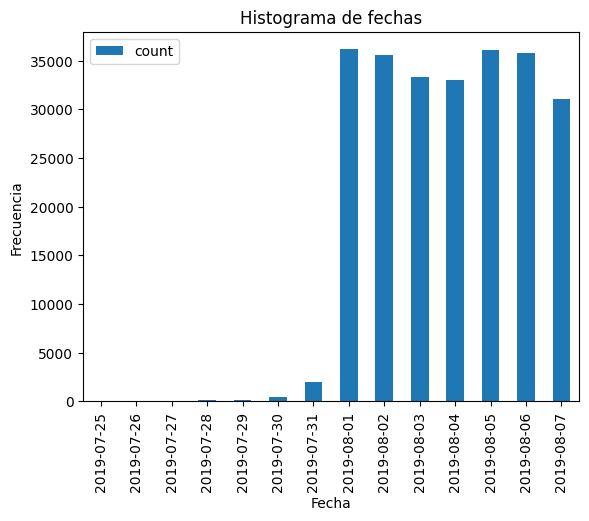

In [ ]:
# Histograma de fechas
date_frequency = data['date'].value_counts().reset_index().sort_values('date')

date_frequency.plot(x='date', y='count', kind='bar')
plt.title('Histograma de fechas')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
plt.show()

El período de tiempo de los datos cubre del 25 de julio de 2019 al 7 de agosto de 2019, sin embargo, los datos más antiguos que el 2 de agosto de 2019 son relativamente pequeños. Consideramos que los datos relevantes para el análisis se tomarán del 1 al 7 de agosto del 2019.

In [ ]:
# Filtrar datos no relevantes
data_filtered = data[data['date'] > pd.to_datetime('2019-07-31').date()]

print(data_filtered.head())

                   event              user_id       date_and_time  group  \
2826            Tutorial  3737462046622621720 2019-08-01 00:07:28    246   
2827    MainScreenAppear  3737462046622621720 2019-08-01 00:08:00    246   
2828    MainScreenAppear  3737462046622621720 2019-08-01 00:08:55    246   
2829  OffersScreenAppear  3737462046622621720 2019-08-01 00:08:58    246   
2830    MainScreenAppear  1433840883824088890 2019-08-01 00:08:59    247   

            date      time  
2826  2019-08-01  00:07:28  
2827  2019-08-01  00:08:00  
2828  2019-08-01  00:08:55  
2829  2019-08-01  00:08:58  
2830  2019-08-01  00:08:59  


In [ ]:
# Porcentaje de datos perdidos
print('Tamaño de datos sin filtrar:', len(data))
print('Tamaño de datos filtrados:', len(data_filtered))

print('\nPorcentaje de datos conservados:', '{0:.2f}'.format(len(data_filtered) / len(data) * 100), '%')
print('Porcentaje de datos filtrados:', '{0:.2f}'.format(100 - len(data_filtered) / len(data) * 100), '%')

print('\n\nUsuarios unicos de datos sin filtrar:', data['user_id'].nunique())
print('Usuarios unicos de datos filtrados:', data_filtered['user_id'].nunique())

print('\nPorcentaje de usuarios de datos conservados:', '{0:.2f}'.format(data_filtered['user_id'].nunique() / data['user_id'].nunique() * 100), '%')
print('Porcentaje de usuarios de datos filtrados:', '{0:.2f}'.format(100 - data_filtered['user_id'].nunique() / data['user_id'].nunique() * 100), '%')

Tamaño de datos sin filtrar: 243713
Tamaño de datos filtrados: 240887

Porcentaje de datos conservados: 98.84 %
Porcentaje de datos filtrados: 1.16 %


Usuarios unicos de datos sin filtrar: 7551
Usuarios unicos de datos filtrados: 7534

Porcentaje de usuarios de datos conservados: 99.77 %
Porcentaje de usuarios de datos filtrados: 0.23 %


Conservamos más del 98.8% de los datos originales y más del 99.7% de los clientes al filtrar las fechas no relevantes.

In [ ]:
# Usuarios por evento
print('Usuarios por grupo:\n', data_filtered.groupby('group')['user_id'].nunique())

Usuarios por grupo:
 group
246    2484
247    2513
248    2537
Name: user_id, dtype: int64


Mantenemos casi el mismo número de usuarios por grupo.

# Estudiar el embudo de eventos

In [ ]:
# Eventos y su frecuencia
print('Frecuencia de eventos:\n', data_filtered['event'].value_counts())

Frecuencia de eventos:
 event
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: count, dtype: int64


In [ ]:
# Usuarios por evento
users_per_event = data_filtered.groupby('event').agg({'user_id': 'nunique'}).sort_values('user_id', ascending=False).reset_index()
users_per_event.columns = ['event', 'n_users']

print('Numero de usuarios por evento:\n', users_per_event)

Numero de usuarios por evento:
                      event  n_users
0         MainScreenAppear     7419
1       OffersScreenAppear     4593
2         CartScreenAppear     3734
3  PaymentScreenSuccessful     3539
4                 Tutorial      840


Considerando el flujo de clientes a través de los eventos, podemos concluir que el orden de eventos va de mayor frecuencia a menor frecuencia, aunque vamos a considerar al tutorial como un evento opcional, por el cual posiblemente no pasen todos los usuarios y que se puede acceder sin importar el orden de eventos.

La secuencia de eventos sería la siguiente:

Main screen appear ▶ Offer screen appear ▶ Cart screen appear ▶ Payment screen successful


In [ ]:
# tasa de retencion con respecto al evento anterior
users_per_event['n_users_previous_event'] = users_per_event['n_users'].shift()
users_per_event['retention_rate'] = users_per_event['n_users'] / users_per_event['n_users_previous_event']
users_per_event['dropoff_rate'] = 1 - users_per_event['retention_rate']

print(users_per_event)

                     event  n_users  n_users_previous_event  retention_rate  \
0         MainScreenAppear     7419                     NaN             NaN   
1       OffersScreenAppear     4593                  7419.0        0.619086   
2         CartScreenAppear     3734                  4593.0        0.812976   
3  PaymentScreenSuccessful     3539                  3734.0        0.947777   
4                 Tutorial      840                  3539.0        0.237355   

   dropoff_rate  
0           NaN  
1      0.380914  
2      0.187024  
3      0.052223  
4      0.762645  


In [ ]:
fig = go.Figure(go.Funnel(
    x=[7419, 4592, 3734, 3539],
    y=['MainScreenAppear', 'OfferScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'],
    textinfo = 'value+percent initial'
    ))
fig.show()

Del total de usuarios que iniciaron en el primer evento, MainScreenAppear, el 48% de los usuarios recorrieron todos los eventos hasta llegar a PaymentScreenSuccessful.
La etapa en la que hay menos retención de usuarios en comparación del evento anterior es el embudo de MainScreenAppear a OfferScreenAppear.

# Estudiar los resultados del experimento

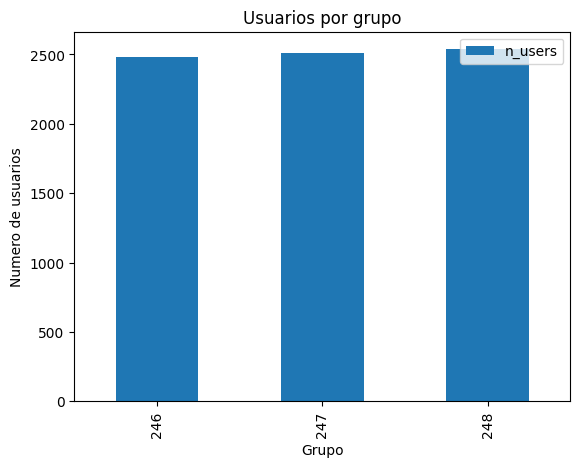

In [ ]:
# Usuarios por grupo
users_per_group = data_filtered.groupby('group').agg({'user_id': 'nunique'}).reset_index()
users_per_group.columns = ['group', 'n_users']

users_per_group.plot(x='group', y='n_users', kind='bar')
plt.title('Usuarios por grupo')
plt.xlabel('Grupo')
plt.ylabel('Numero de usuarios')
plt.show()

In [ ]:
# Separar usuarios por grupo
total_users = users_per_group['n_users'].sum()

# Tamano de muestra esperado
expected = np.array([total_users/3, total_users/3, total_users/3])

# Tamano de muestra observado
observed = np.array([
    users_per_group.loc[0, 'n_users'],
    users_per_group.loc[1, 'n_users'],
    users_per_group.loc[2, 'n_users']])

# Disparidad de proporcion de la muestra
chi = st.chisquare(f_obs=observed, f_exp=expected)

print('Valor-p:', chi[1])

if chi[1] < 0.01:
  print('Disparidad de proporcion en las muestras detectada')
else:
  print('No se detecto dispardad de proporcion en las muestras')

Valor-p: 0.7554347210047129
No se detecto dispardad de proporcion en las muestras


In [ ]:
# Etapas del embudo
funnel_stages = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

In [ ]:
# Calcular tasa de conversion en cada etapa

def get_funnel_counts(data_group, funnel_stages):
  # Usuarios unicos en cada etapa
  funnel_users = []
  for stage in funnel_stages:
    users_at_stage = data_group[data_group['event'] == stage]['user_id'].nunique()
    funnel_users.append(users_at_stage)
  return funnel_users

In [ ]:
# Dataframe filtrado por grupos
data_246 = data_filtered[data_filtered['group'] == 246]
data_247 = data_filtered[data_filtered['group'] == 247]
data_248 = data_filtered[data_filtered['group'] == 248]

# Calcular usaurios para cada embudo, para cada grupo
funnel_counts_246 = get_funnel_counts(data_246, funnel_stages)
funnel_counts_247 = get_funnel_counts(data_247, funnel_stages)
funnel_counts_248 = get_funnel_counts(data_248, funnel_stages)

In [ ]:
def get_funnel(data_group):
  funnel = data_group.groupby('event').agg({'user_id': 'nunique'}).sort_values('user_id', ascending=False).reset_index().drop(4)
  funnel.columns = ['event', 'n_users']
  return funnel

funnel_246 = get_funnel(data_246)
funnel_247 = get_funnel(data_247)
funnel_248 = get_funnel(data_248)

print(funnel_246)
print(funnel_247)
print(funnel_248)

                     event  n_users
0         MainScreenAppear     2450
1       OffersScreenAppear     1542
2         CartScreenAppear     1266
3  PaymentScreenSuccessful     1200
                     event  n_users
0         MainScreenAppear     2476
1       OffersScreenAppear     1520
2         CartScreenAppear     1238
3  PaymentScreenSuccessful     1158
                     event  n_users
0         MainScreenAppear     2493
1       OffersScreenAppear     1531
2         CartScreenAppear     1230
3  PaymentScreenSuccessful     1181


In [ ]:
# Anadir columna de converison con respecto al evento anterior
funnel_246['conversion_rate'] = funnel_246['n_users'] / funnel_246['n_users'].shift()
funnel_246['conversion_rate'].fillna(1, inplace=True)

funnel_247['conversion_rate'] = funnel_247['n_users'] / funnel_247['n_users'].shift()
funnel_247['conversion_rate'].fillna(1, inplace=True)

funnel_248['conversion_rate'] = funnel_248['n_users'] / funnel_248['n_users'].shift()
funnel_248['conversion_rate'].fillna(1, inplace=True)

print(funnel_246)
print(funnel_247)
print(funnel_248)

                     event  n_users  conversion_rate
0         MainScreenAppear     2450         1.000000
1       OffersScreenAppear     1542         0.629388
2         CartScreenAppear     1266         0.821012
3  PaymentScreenSuccessful     1200         0.947867
                     event  n_users  conversion_rate
0         MainScreenAppear     2476         1.000000
1       OffersScreenAppear     1520         0.613893
2         CartScreenAppear     1238         0.814474
3  PaymentScreenSuccessful     1158         0.935380
                     event  n_users  conversion_rate
0         MainScreenAppear     2493         1.000000
1       OffersScreenAppear     1531         0.614120
2         CartScreenAppear     1230         0.803396
3  PaymentScreenSuccessful     1181         0.960163


/tmp/ipython-input-3979858509.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-3979858509.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

In [ ]:
# Asignar un id a los eventos por simplicidad
funnel_246['event_id'] = [1, 2, 3, 4]
funnel_247['event_id'] = [1, 2, 3, 4]
funnel_248['event_id'] = [1, 2, 3, 4]

In [ ]:
# Test de proporciones para cada etapa del embudo
def test_conversion_stage(funnelA, funnelB, event):
  # Usuarios totales
  nobA = funnelA.loc[0, 'n_users']
  nobB = funnelB.loc[0, 'n_users']

  # Usuarios en caada evento evento
  countA = funnelA.loc[funnelA['event'] == event, 'n_users'].values[0]
  countB = funnelB.loc[funnelB['event'] == event, 'n_users'].values[0]

  return smp.proportions_ztest([countA, countB],
                             [nobA, nobB])[1]

Entramos en una comparación múltiple de pruebas A/A/B: tres pruebas, aprovechamos el hecho de que son pocas pruebas y se empleará 'El procedimiento de Bonferroni' para corregir el nivel de significancia estadística $\alpha$.

$\alpha_1 = . . .  = \alpha_m = \alpha / m$

Sustituyendo

$\alpha_1 = \alpha_2 = \alpha_3 = 0.05/3 = 0.017$

In [ ]:
# Pruebas A/A
alpha = 0.017

for i in [1, 2, 3]:
  event = funnel_stages[i]
  pval = test_conversion_stage(funnel_246, funnel_247, event)
  print(f'Prueba A/A evento: \'{event}\'')
  print(f'Valor-p: {'{0:.3f}'.format(pval)}')
  if pval < alpha:
    print('Existe diferencia estadistica significante\n')
  else:
    print('No hay diferencia estadisticamente significante\n')

Prueba A/A evento: 'OffersScreenAppear'
Valor-p: 0.262
No hay diferencia estadisticamente significante

Prueba A/A evento: 'CartScreenAppear'
Valor-p: 0.240
No hay diferencia estadisticamente significante

Prueba A/A evento: 'PaymentScreenSuccessful'
Valor-p: 0.120
No hay diferencia estadisticamente significante



In [ ]:
# Pruebas A/B
for i in [1, 2, 3]:
  event = funnel_stages[i]
  pval = test_conversion_stage(funnel_246, funnel_248, event)
  print(f'Prueba A/B evento: \'{event}\'')
  print(f'Valor-p: {'{0:.3f}'.format(pval)}')
  if pval < alpha:
    print('Existe diferencia estadistica significante\n')
  else:
    print('No hay diferencia estadisticamente significante\n')

Prueba A/B evento: 'OffersScreenAppear'
Valor-p: 0.268
No hay diferencia estadisticamente significante

Prueba A/B evento: 'CartScreenAppear'
Valor-p: 0.101
No hay diferencia estadisticamente significante

Prueba A/B evento: 'PaymentScreenSuccessful'
Valor-p: 0.258
No hay diferencia estadisticamente significante



In [ ]:
fig = go.Figure()

fig.add_trace(go.Funnel(
    name = 'Grupo 246',
    y = funnel_stages,
    x = funnel_246['n_users'],
    textinfo = 'value+percent initial'))

fig.add_trace(go.Funnel(
    name = 'Grupo 247',
    orientation = 'h',
    y = funnel_stages,
    x = funnel_247['n_users'],
    textposition = 'inside',
    textinfo = 'value+percent initial'))

fig.add_trace(go.Funnel(
    name = 'Grupo 248',
    orientation = 'h',
    y = funnel_stages,
    x = funnel_248['n_users'],
    textposition = 'inside',
    textinfo = 'value+percent initial'
))

fig.show()

# Conclusión
La prueba A/A/B no ha arrojado significancia estadística en ninguno de los eventos, ni en las pruebas A/A, que nos indica que ambos grupos de control son estadísticamente similares, ni en las pruebas A/B, que sugiere que el grupo experimental B no está afectando el comportamiento de los usuarios en el análisis de embudos.

Es importante notar que nuestro análisis se extiende por 5 días, del 1 al 5 de agosto del 2019, usando la calculadora de duración de prueba https://vwo.com/tools/ab-duration-calculator/, sugiere que con un tráfico de usuarios promedio de 3600, un índice de conversión estimado del 48%,  una mejora mínima a detectar de 1.7 y tres grupos, la duration mínima de la prueba debería ser de 50 días.

Es seguro afirmar que nuestra prueba contiene muy pocos datos para poder aterrizar conclusiones estadísticas.